<a href="https://colab.research.google.com/github/JordanBaker78/Data205_JordanBaker/blob/main/Copy_of_Capstone_Proj_extracode_PASSING.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import plotly.graph_objects as go
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [9]:
import statsmodels.formula.api as smf
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from numpy._core.fromnumeric import std
import scipy.stats as stats

In [4]:
stats_2023 = pd.read_csv('https://raw.githubusercontent.com/JordanBaker78/Data205_JordanBaker/refs/heads/main/Project_Datasets/Stats-2023.csv')
stats_2022 = pd.read_csv('https://raw.githubusercontent.com/JordanBaker78/Data205_JordanBaker/refs/heads/main/Project_Datasets/Stats-2022.csv')
stats_2021 = pd.read_csv('https://raw.githubusercontent.com/JordanBaker78/Data205_JordanBaker/refs/heads/main/Project_Datasets/Stats-2021.csv')
stats_2020 = pd.read_csv('https://raw.githubusercontent.com/JordanBaker78/Data205_JordanBaker/refs/heads/main/Project_Datasets/Stats-2020.csv')
stats_2019 = pd.read_csv('https://raw.githubusercontent.com/JordanBaker78/Data205_JordanBaker/refs/heads/main/Project_Datasets/Stats-2019.csv')

In [5]:
stats_df = pd.concat((stats_2023, stats_2022, stats_2021, stats_2020, stats_2019))
stats_df.tail()

,season,event_date,nano,market,name,alias,rush_att,rush_yds,rush_tds,pass_cmp,...,penalty_yds,first_downs,third_down_conv,third_down_att,third_down_conv_pct,fourth_down_conv,fourth_down_att,fourth_down_conv_pct,time_of_possession,boxscore_stats_link
529,2019,2020-01-19,oiGiwWPf0UqMC,Kansas City,Chiefs,KC,27,112,2,23,...,61,27,6,10,0.600,1,1,1.000,1790,https://www.pro-football-reference.com/boxscor...
530,2019,2020-01-19,D5QY6bOxfn8ZL,Green Bay,Packers,GB,16,62,1,31,...,46,21,3,9,0.333,2,2,1.000,1873,https://www.pro-football-reference.com/boxscor...
531,2019,2020-01-19,IwSI92ZDKoazn,San Francisco,49ers,SF,42,285,4,6,...,10,19,4,10,0.400,0,0,0.000,1727,https://www.pro-football-reference.com/boxscor...
532,2019,2020-02-02,IwSI92ZDKoazn,San Francisco,49ers,SF,22,141,1,20,...,45,21,3,8,0.375,0,1,0.000,1607,https://www.pro-football-reference.com/boxscor...
533,2019,2020-02-02,oiGiwWPf0UqMC,Kansas City,Chiefs,KC,29,129,2,26,...,24,26,6,14,0.429,2,3,0.667,1993,https://www.pro-football-reference.com/boxscor...


In [6]:
#add Column named "pass_avg"
pass_avg = stats_df['pass_yds'] / stats_df['pass_cmp']
stats_df.insert(15, 'pass_avg', pass_avg)
#stats_df.head()

,season,event_date,nano,market,name,alias,rush_att,rush_yds,rush_tds,pass_cmp,...,penalty_yds,first_downs,third_down_conv,third_down_att,third_down_conv_pct,fourth_down_conv,fourth_down_att,fourth_down_conv_pct,time_of_possession,boxscore_stats_link
0,2023,2024-01-28,zyhFXj1nywrm1,Baltimore,Ravens,BAL,16,81,0,20,...,95,16,3,11,0.273,2,2,1.000,1350,https://www.pro-football-reference.com/boxscor...
1,2023,2024-01-28,oiGiwWPf0UqMC,Kansas City,Chiefs,KC,32,89,1,30,...,30,22,8,18,0.444,1,2,0.500,2250,https://www.pro-football-reference.com/boxscor...
2,2023,2024-01-28,IwSI92ZDKoazn,San Francisco,49ers,SF,33,155,3,20,...,20,23,6,12,0.500,0,1,0.000,1932,https://www.pro-football-reference.com/boxscor...
3,2023,2024-01-28,FCuH1wdksA2DQ,Detroit,Lions,DET,29,182,3,25,...,15,28,6,12,0.500,1,3,0.333,1668,https://www.pro-football-reference.com/boxscor...
4,2023,2024-01-21,oiGiwWPf0UqMC,Kansas City,Chiefs,KC,24,146,1,17,...,15,21,1,5,0.200,0,0,0.000,1377,https://www.pro-football-reference.com/boxscor...


In [10]:
stats_2019 = stats_df[stats_df['season'] == 2019]
stats_2020 = stats_df[stats_df['season'] == 2020]
stats_2021 = stats_df[stats_df['season'] == 2021]
stats_2022 = stats_df[stats_df['season'] == 2022]
stats_2023 = stats_df[stats_df['season'] == 2023]
#stats_2019.head()

In [15]:
passing_2019 = stats_2019[['name', 'pass_att', 'pass_cmp', 'pass_avg', 'pass_yds', 'pass_tds', 'pass_int', 'passer_rating', 'net_pass_yds', 'times_sacked', 'yds_sacked_for']]
passing_2020 = stats_2020[['name', 'pass_att', 'pass_cmp', 'pass_avg', 'pass_yds', 'pass_tds', 'pass_int', 'passer_rating', 'net_pass_yds', 'times_sacked', 'yds_sacked_for']]
passing_2021 = stats_2021[['name', 'pass_att', 'pass_cmp', 'pass_avg', 'pass_yds', 'pass_tds', 'pass_int', 'passer_rating', 'net_pass_yds', 'times_sacked', 'yds_sacked_for']]
passing_2022 = stats_2022[['name', 'pass_att', 'pass_cmp', 'pass_avg', 'pass_yds', 'pass_tds', 'pass_int', 'passer_rating', 'net_pass_yds', 'times_sacked', 'yds_sacked_for']]
passing_2023 = stats_2023[['name', 'pass_att', 'pass_cmp', 'pass_avg', 'pass_yds', 'pass_tds', 'pass_int', 'passer_rating', 'net_pass_yds', 'times_sacked', 'yds_sacked_for']]
passing_total = stats_df[['season', 'name', 'pass_att', 'pass_cmp', 'pass_avg', 'pass_yds', 'pass_tds', 'pass_int', 'passer_rating', 'net_pass_yds', 'times_sacked', 'yds_sacked_for']]
passing_2019.head()

,name,pass_att,pass_cmp,pass_avg,pass_yds,pass_tds,pass_int,passer_rating,net_pass_yds,times_sacked,yds_sacked_for
0,Packers,30,18,11.277778,203,1,0,91.389,166,5,37
1,Bears,45,26,8.769231,228,0,1,62.083,208,5,20
2,Falcons,46,33,9.212121,304,2,2,85.779,272,4,32
3,Vikings,10,8,12.250000,98,1,0,140.833,97,1,1
4,Bills,37,24,10.583333,254,1,2,71.227,242,1,12


In [12]:
all_teams_total_pass_2019 = stats_2019.groupby('name')['pass_yds'].sum().reset_index()
all_teams_total_pass_2020 = stats_2020.groupby('name')['pass_yds'].sum().reset_index()
all_teams_total_pass_2021 = stats_2021.groupby('name')['pass_yds'].sum().reset_index()
all_teams_total_pass_2022 = stats_2022.groupby('name')['pass_yds'].sum().reset_index()
all_teams_total_pass_2023 = stats_2023.groupby('name')['pass_yds'].sum().reset_index()

In [14]:
all_teams_passer_rating_2019 = stats_2019.groupby('name')['passer_rating'].mean().reset_index()
all_teams_passer_rating_2020 = stats_2020.groupby('name')['passer_rating'].mean().reset_index()
all_teams_passer_rating_2021 = stats_2021.groupby('name')['passer_rating'].mean().reset_index()
all_teams_passer_rating_2022 = stats_2022.groupby('name')['passer_rating'].mean().reset_index()
all_teams_passer_rating_2023 = stats_2023.groupby('name')['passer_rating'].mean().reset_index()

In [16]:
all_teams_pass_tds_2019 = stats_2019.groupby('name')['pass_tds'].sum().reset_index()
all_teams_pass_tds_2020 = stats_2020.groupby('name')['pass_tds'].sum().reset_index()
all_teams_pass_tds_2021 = stats_2021.groupby('name')['pass_tds'].sum().reset_index()
all_teams_pass_tds_2022 = stats_2022.groupby('name')['pass_tds'].sum().reset_index()
all_teams_pass_tds_2023 = stats_2023.groupby('name')['pass_tds'].sum().reset_index()

In [17]:
all_teams_pass_avg_2019 = stats_2019.groupby('name')['pass_avg'].mean().reset_index()
all_teams_pass_avg_2020 = stats_2020.groupby('name')['pass_avg'].mean().reset_index()
all_teams_pass_avg_2021 = stats_2021.groupby('name')['pass_avg'].mean().reset_index()
all_teams_pass_avg_2022 = stats_2022.groupby('name')['pass_avg'].mean().reset_index()
all_teams_pass_avg_2023 = stats_2023.groupby('name')['pass_avg'].mean().reset_index()

In [18]:
all_teams_rush_pass_int_2019 = stats_2019.groupby('name')['pass_int'].sum().reset_index()
all_teams_rush_pass_int_2020 = stats_2020.groupby('name')['pass_int'].sum().reset_index()
all_teams_rush_pass_int_2021 = stats_2021.groupby('name')['pass_int'].sum().reset_index()
all_teams_rush_pass_int_2022 = stats_2022.groupby('name')['pass_int'].sum().reset_index()
all_teams_rush_pass_int_2023 = stats_2023.groupby('name')['pass_int'].sum().reset_index()

In [20]:
total_pass_with_rank_19 = all_teams_total_pass_2019.copy()
total_pass_with_rank_19['pass_yds_rank'] = total_pass_with_rank_19['pass_yds'].rank(ascending=False, method='min')
passer_rating_with_rank_19 = all_teams_passer_rating_2019.copy()
passer_rating_with_rank_19['passer_rating_rank'] = passer_rating_with_rank_19['passer_rating'].rank(ascending=False, method='min')
pass_avg_with_rank_19 = all_teams_pass_avg_2019.copy()
pass_avg_with_rank_19['pass_avg_rank'] = pass_avg_with_rank_19['pass_avg'].rank(ascending=False, method='min')
pass_tds_with_rank_19 = all_teams_pass_tds_2019.copy()
pass_tds_with_rank_19['pass_tds_rank'] = pass_tds_with_rank_19['pass_tds'].rank(ascending=False, method='min')
pass_int_with_rank_19 = all_teams_rush_pass_int_2019.copy()
pass_int_with_rank_19['pass_int_rank'] = pass_int_with_rank_19['pass_int'].rank(ascending=True, method='min')


In [23]:
pass_rank_19 = pd.merge(total_pass_with_rank_19[['name', 'pass_yds', 'pass_yds_rank']],
                          pass_avg_with_rank_19[['name', 'pass_avg', 'pass_avg_rank']],
                          on='name')
pass_rank_19 = pd.merge(pass_rank_19,
                          pass_tds_with_rank_19[['name', 'pass_tds', 'pass_tds_rank']],
                          on='name')
pass_rank_19 = pd.merge(pass_rank_19,
                          pass_int_with_rank_19[['name', 'pass_int', 'pass_int_rank']],
                          on='name')
pass_rank_19 = pd.merge(pass_rank_19,
                          passer_rating_with_rank_19[['name', 'passer_rating', 'passer_rating_rank']],
                          on='name')
pass_rank_19.sort_values(by='pass_yds_rank')

,name,pass_yds,pass_yds_rank,pass_avg,pass_avg_rank,pass_tds,pass_tds_rank,pass_int,pass_int_rank,passer_rating,passer_rating_rank
9,Chiefs,5591,1.0,12.328249,6.0,40,1.0,7,3.0,104.542000,4.0
6,Buccaneers,5127,2.0,13.566821,1.0,33,5.0,30,32.0,86.534937,19.0
14,Falcons,5049,3.0,11.091166,20.0,29,12.0,15,20.0,94.913438,12.0
11,Cowboys,4902,4.0,12.611722,5.0,30,7.0,11,14.0,100.826313,6.0
29,Texans,4718,5.0,11.588473,13.0,30,7.0,14,19.0,96.763000,11.0
27,Seahawks,4712,6.0,12.643890,4.0,33,5.0,6,1.0,106.601833,3.0
26,Saints,4689,7.0,10.533982,30.0,37,3.0,7,3.0,108.047000,2.0
24,Rams,4669,8.0,12.027474,10.0,22,19.0,17,25.0,85.411750,24.0
8,Chargers,4648,9.0,12.105603,8.0,24,17.0,20,29.0,91.818375,14.0
20,Packers,4586,10.0,11.499452,15.0,30,7.0,6,1.0,96.798556,10.0


In [24]:
total_pass_with_rank_20 = all_teams_total_pass_2020.copy()
total_pass_with_rank_20['pass_yds_rank'] = total_pass_with_rank_20['pass_yds'].rank(ascending=False, method='min')
passer_rating_with_rank_20 = all_teams_passer_rating_2020.copy()
passer_rating_with_rank_20['passer_rating_rank'] = passer_rating_with_rank_20['passer_rating'].rank(ascending=False, method='min')
pass_avg_with_rank_20 = all_teams_pass_avg_2020.copy()
pass_avg_with_rank_20['pass_avg_rank'] = pass_avg_with_rank_20['pass_avg'].rank(ascending=False, method='min')
pass_tds_with_rank_20 = all_teams_pass_tds_2020.copy()
pass_tds_with_rank_20['pass_tds_rank'] = pass_tds_with_rank_20['pass_tds'].rank(ascending=False, method='min')
pass_int_with_rank_20 = all_teams_rush_pass_int_2020.copy()
pass_int_with_rank_20['pass_int_rank'] = pass_int_with_rank_20['pass_int'].rank(ascending=True, method='min')

In [25]:
pass_rank_20 = pd.merge(total_pass_with_rank_20[['name', 'pass_yds', 'pass_yds_rank']],
                          pass_avg_with_rank_20[['name', 'pass_avg', 'pass_avg_rank']],
                          on='name')
pass_rank_20 = pd.merge(pass_rank_20,
                          pass_tds_with_rank_20[['name', 'pass_tds', 'pass_tds_rank']],
                          on='name')
pass_rank_20 = pd.merge(pass_rank_20,
                          pass_int_with_rank_20[['name', 'pass_int', 'pass_int_rank']],
                          on='name')
pass_rank_20 = pd.merge(pass_rank_20,
                          passer_rating_with_rank_20[['name', 'passer_rating', 'passer_rating_rank']],
                          on='name')
pass_rank_20.sort_values(by='pass_yds_rank')

,name,pass_yds,pass_yds_rank,pass_avg,pass_avg_rank,pass_tds,pass_tds_rank,pass_int,pass_int_rank,passer_rating,passer_rating_rank
9,Chiefs,5921,1.0,11.821485,7.0,44,4.0,10,5.0,105.269895,4.0
6,Buccaneers,5837,2.0,11.828914,6.0,52,2.0,15,24.0,101.664550,8.0
3,Bills,5603,3.0,11.574241,11.0,45,3.0,12,13.0,104.943263,5.0
20,Packers,4941,4.0,11.543078,12.0,53,1.0,6,1.0,118.021000,1.0
29,Texans,4843,5.0,12.817382,1.0,33,9.0,7,2.0,111.626437,2.0
28,Steelers,4630,6.0,9.799351,32.0,39,6.0,15,24.0,93.953765,16.0
14,Falcons,4620,7.0,11.417313,13.0,27,14.0,11,8.0,93.161250,18.0
8,Chargers,4548,8.0,11.393827,14.0,31,11.0,10,5.0,99.507125,10.0
24,Rams,4541,9.0,10.920291,21.0,22,24.0,14,20.0,90.583611,21.0
11,Cowboys,4511,10.0,10.899341,22.0,25,20.0,13,14.0,90.366875,22.0


In [26]:
total_pass_with_rank_21 = all_teams_total_pass_2021.copy()
total_pass_with_rank_21['pass_yds_rank'] = total_pass_with_rank_21['pass_yds'].rank(ascending=False, method='min')
passer_rating_with_rank_21 = all_teams_passer_rating_2021.copy()
passer_rating_with_rank_21['passer_rating_rank'] = passer_rating_with_rank_21['passer_rating'].rank(ascending=False, method='min')
pass_avg_with_rank_21 = all_teams_pass_avg_2021.copy()
pass_avg_with_rank_21['pass_avg_rank'] = pass_avg_with_rank_21['pass_avg'].rank(ascending=False, method='min')
pass_tds_with_rank_21 = all_teams_pass_tds_2021.copy()
pass_tds_with_rank_21['pass_tds_rank'] = pass_tds_with_rank_21['pass_tds'].rank(ascending=False, method='min')
pass_int_with_rank_21 = all_teams_rush_pass_int_2021.copy()
pass_int_with_rank_21['pass_int_rank'] = pass_int_with_rank_21['pass_int'].rank(ascending=True, method='min')

In [28]:
pass_rank_21 = pd.merge(total_pass_with_rank_21[['name', 'pass_yds', 'pass_yds_rank']],
                          pass_avg_with_rank_21[['name', 'pass_avg', 'pass_avg_rank']],
                          on='name')
pass_rank_21 = pd.merge(pass_rank_21,
                          pass_tds_with_rank_21[['name', 'pass_tds', 'pass_tds_rank']],
                          on='name')
pass_rank_21 = pd.merge(pass_rank_21,
                          pass_int_with_rank_21[['name', 'pass_int', 'pass_int_rank']],
                          on='name')
pass_rank_21 = pd.merge(pass_rank_21,
                          passer_rating_with_rank_21[['name', 'passer_rating', 'passer_rating_rank']],
                          on='name')
pass_rank_21.sort_values(by='pass_yds_rank')

,name,pass_yds,pass_yds_rank,pass_avg,pass_avg_rank,pass_tds,pass_tds_rank,pass_int,pass_int_rank,passer_rating,passer_rating_rank
24,Rams,6121,1.0,12.346527,2.0,50,1.0,21,31.0,105.819333,2.0
9,Chiefs,5996,2.0,11.171704,17.0,49,2.0,16,21.0,102.604800,6.0
6,Buccaneers,5983,3.0,10.888075,23.0,46,3.0,13,9.0,100.392947,8.0
2,Bengals,5917,4.0,12.086163,3.0,42,5.0,16,21.0,104.756810,3.0
11,Cowboys,5233,5.0,11.316460,11.0,41,6.0,12,7.0,103.111722,5.0
23,Raiders,5118,6.0,11.290158,12.0,24,17.0,15,15.0,92.792056,16.0
3,Bills,5087,7.0,11.404322,8.0,45,4.0,16,21.0,97.198895,11.0
8,Chargers,5014,8.0,11.282932,13.0,38,8.0,15,15.0,98.238235,10.0
0,49ers,4972,9.0,13.009690,1.0,28,12.0,17,24.0,96.561800,12.0
7,Cardinals,4756,10.0,10.958996,21.0,27,13.0,13,9.0,98.895389,9.0


In [29]:
total_pass_with_rank_22 = all_teams_total_pass_2022.copy()
total_pass_with_rank_22['pass_yds_rank'] = total_pass_with_rank_22['pass_yds'].rank(ascending=False, method='min')
passer_rating_with_rank_22 = all_teams_passer_rating_2022.copy()
passer_rating_with_rank_22['passer_rating_rank'] = passer_rating_with_rank_22['passer_rating'].rank(ascending=False, method='min')
pass_avg_with_rank_22 = all_teams_pass_avg_2022.copy()
pass_avg_with_rank_22['pass_avg_rank'] = pass_avg_with_rank_22['pass_avg'].rank(ascending=False, method='min')
pass_tds_with_rank_22 = all_teams_pass_tds_2022.copy()
pass_tds_with_rank_22['pass_tds_rank'] = pass_tds_with_rank_22['pass_tds'].rank(ascending=False, method='min')
pass_int_with_rank_22 = all_teams_rush_pass_int_2022.copy()
pass_int_with_rank_22['pass_int_rank'] = pass_int_with_rank_22['pass_int'].rank(ascending=True, method='min')

In [30]:
pass_rank_22 = pd.merge(total_pass_with_rank_22[['name', 'pass_yds', 'pass_yds_rank']],
                          pass_avg_with_rank_22[['name', 'pass_avg', 'pass_avg_rank']],
                          on='name')
pass_rank_22 = pd.merge(pass_rank_22,
                          pass_tds_with_rank_22[['name', 'pass_tds', 'pass_tds_rank']],
                          on='name')
pass_rank_22 = pd.merge(pass_rank_22,
                          pass_int_with_rank_22[['name', 'pass_int', 'pass_int_rank']],
                          on='name')
pass_rank_22 = pd.merge(pass_rank_22,
                          passer_rating_with_rank_22[['name', 'passer_rating', 'passer_rating_rank']],
                          on='name')
pass_rank_22.sort_values(by='pass_yds_rank')

,name,pass_yds,pass_yds_rank,pass_avg,pass_avg_rank,pass_tds,pass_tds_rank,pass_int,pass_int_rank,passer_rating,passer_rating_rank
9,Chiefs,5794,1.0,12.069564,5.0,46,1.0,12,9.0,105.726632,1.0
2,Bengals,5241,2.0,10.774390,21.0,39,2.0,14,14.0,99.973947,4.0
6,Buccaneers,5097,3.0,9.643900,31.0,28,11.0,11,7.0,89.167222,16.0
31,Vikings,5089,4.0,10.534294,23.0,32,6.0,15,21.0,94.099556,9.0
8,Chargers,5064,5.0,10.092131,28.0,27,13.0,10,6.0,94.188722,8.0
12,Dolphins,4985,6.0,13.070454,1.0,31,8.0,17,26.0,92.212111,13.0
3,Bills,4908,7.0,12.189895,3.0,38,3.0,17,26.0,93.091556,11.0
0,49ers,4692,8.0,12.315718,2.0,33,4.0,9,3.0,103.150750,2.0
17,Jaguars,4653,9.0,10.525758,24.0,30,9.0,14,14.0,91.150947,15.0
13,Eagles,4639,10.0,12.013783,7.0,27,13.0,9,3.0,98.101526,6.0


In [31]:
total_pass_with_rank_23 = all_teams_total_pass_2023.copy()
total_pass_with_rank_23['pass_yds_rank'] = total_pass_with_rank_23['pass_yds'].rank(ascending=False, method='min')
passer_rating_with_rank_23 = all_teams_passer_rating_2023.copy()
passer_rating_with_rank_23['passer_rating_rank'] = passer_rating_with_rank_23['passer_rating'].rank(ascending=False, method='min')
pass_avg_with_rank_23 = all_teams_pass_avg_2023.copy()
pass_avg_with_rank_23['pass_avg_rank'] = pass_avg_with_rank_23['pass_avg'].rank(ascending=False, method='min')
pass_tds_with_rank_23 = all_teams_pass_tds_2023.copy()
pass_tds_with_rank_23['pass_tds_rank'] = pass_tds_with_rank_23['pass_tds'].rank(ascending=False, method='min')
pass_int_with_rank_23 = all_teams_rush_pass_int_2023.copy()
pass_int_with_rank_23['pass_int_rank'] = pass_int_with_rank_23['pass_int'].rank(ascending=True, method='min')

In [32]:
pass_rank_23 = pd.merge(total_pass_with_rank_23[['name', 'pass_yds', 'pass_yds_rank']],
                          pass_avg_with_rank_23[['name', 'pass_avg', 'pass_avg_rank']],
                          on='name')
pass_rank_23 = pd.merge(pass_rank_23,
                          pass_tds_with_rank_23[['name', 'pass_tds', 'pass_tds_rank']],
                          on='name')
pass_rank_23 = pd.merge(pass_rank_23,
                          pass_int_with_rank_23[['name', 'pass_int', 'pass_int_rank']],
                          on='name')
pass_rank_23 = pd.merge(pass_rank_23,
                          passer_rating_with_rank_23[['name', 'passer_rating', 'passer_rating_rank']],
                          on='name')
pass_rank_23.sort_values(by='pass_yds_rank')

,name,pass_yds,pass_yds_rank,pass_avg,pass_avg_rank,pass_tds,pass_tds_rank,pass_int,pass_int_rank,passer_rating,passer_rating_rank
19,Lions,5443,1.0,11.377930,11.0,34,4.0,12,10.0,99.829050,4.0
9,Chiefs,5101,2.0,10.431108,25.0,32,7.0,17,25.0,91.764100,15.0
0,49ers,5096,3.0,13.427293,1.0,35,3.0,13,16.0,108.365105,1.0
11,Cowboys,5063,4.0,10.864334,18.0,39,1.0,12,10.0,101.589333,2.0
29,Texans,5033,5.0,12.465948,2.0,30,9.0,8,1.0,98.730579,6.0
12,Dolphins,4897,6.0,11.789258,5.0,31,8.0,16,23.0,97.837556,7.0
6,Buccaneers,4730,7.0,11.555846,7.0,34,4.0,12,10.0,95.855632,9.0
31,Vikings,4700,8.0,11.036743,15.0,30,9.0,19,29.0,91.960000,13.0
3,Bills,4695,9.0,11.165673,14.0,33,6.0,18,27.0,93.228737,12.0
20,Packers,4676,10.0,11.596273,6.0,37,2.0,13,16.0,99.684737,5.0


In [33]:
team_passing_rankings = pd.merge(pass_rank_19[['name', 'pass_yds_rank', 'passer_rating_rank']],
                                  pass_rank_20[['name', 'pass_yds_rank', 'passer_rating_rank']],
                                  on='name',
                                  suffixes=('_2019', '_2020'))
team_passing_rankings = pd.merge(team_passing_rankings,
                                  pass_rank_21[['name', 'pass_yds_rank', 'passer_rating_rank']],
                                  on='name',
                                  suffixes=('', '_2021'))
team_passing_rankings = pd.merge(team_passing_rankings,
                                  pass_rank_22[['name', 'pass_yds_rank', 'passer_rating_rank']],
                                  on='name',
                                  suffixes=('', '_2022'))
team_passing_rankings = pd.merge(team_passing_rankings,
                                  pass_rank_23[['name', 'pass_yds_rank', 'passer_rating_rank']],
                                  on='name',
                                  suffixes=('', '_2023'))
team_passing_rankings

,name,pass_yds_rank_2019,passer_rating_rank_2019,pass_yds_rank_2020,passer_rating_rank_2020,pass_yds_rank,passer_rating_rank,pass_yds_rank_2022,passer_rating_rank_2022,pass_yds_rank_2023,passer_rating_rank_2023
0,49ers,11.0,9.0,16.0,20.0,9.0,12.0,8.0,2.0,3.0,1.0
1,Bears,27.0,21.0,20.0,24.0,26.0,28.0,32.0,29.0,28.0,25.0
2,Bengals,22.0,32.0,26.0,26.0,4.0,3.0,2.0,4.0,17.0,11.0
3,Bills,25.0,20.0,3.0,5.0,7.0,11.0,7.0,11.0,9.0,12.0
4,Broncos,29.0,23.0,28.0,32.0,21.0,15.0,16.0,21.0,25.0,10.0
5,Browns,23.0,31.0,18.0,13.0,28.0,22.0,24.0,20.0,13.0,30.0
6,Buccaneers,2.0,19.0,2.0,8.0,3.0,8.0,3.0,16.0,7.0,9.0
7,Cardinals,24.0,17.0,21.0,14.0,10.0,9.0,18.0,28.0,27.0,24.0
8,Chargers,9.0,14.0,8.0,10.0,8.0,10.0,5.0,8.0,15.0,18.0
9,Chiefs,1.0,4.0,1.0,4.0,2.0,6.0,1.0,1.0,2.0,15.0


In [34]:
win_pct_2019 = pd.read_csv('https://raw.githubusercontent.com/JordanBaker78/Data205_JordanBaker/refs/heads/main/Project_Datasets/Win%20percentage%20-%202019%20win%20pct.csv')
win_pct_2020 = pd.read_csv('https://raw.githubusercontent.com/JordanBaker78/Data205_JordanBaker/refs/heads/main/Project_Datasets/Win%20percentage%20-%202020%20win%20pct.csv')
win_pct_2021 = pd.read_csv('https://raw.githubusercontent.com/JordanBaker78/Data205_JordanBaker/refs/heads/main/Project_Datasets/Win%20percentage%20-%202021%20win%20pct.csv')
win_pct_2022 = pd.read_csv('https://raw.githubusercontent.com/JordanBaker78/Data205_JordanBaker/refs/heads/main/Project_Datasets/Win%20percentage%20-%202022%20win%20pct.csv')
win_pct_2023 = pd.read_csv('https://raw.githubusercontent.com/JordanBaker78/Data205_JordanBaker/refs/heads/main/Project_Datasets/Win%20percentage%20-%202023%20win%20pct.csv')
win_pct_2020.head()

,Unnamed: 0,name,wins,losses,ties,win_percentage
0,1,Chiefs,14,2,0,0.875
1,2,Packers,13,3,0,0.813
2,3,Bills,13,3,0,0.813
3,4,Saints,12,4,0,0.750
4,5,Steelers,12,4,0,0.750


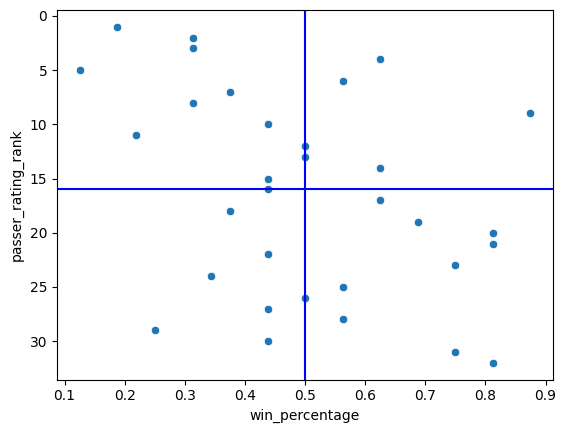

In [36]:
sns.scatterplot(x = win_pct_2019['win_percentage'], y = pass_rank_19.sort_values(by = 'passer_rating_rank', ascending=False)['passer_rating_rank'])
plt.axhline(y=16, color = 'b', linestyle='-')
plt.axvline(x=0.5, color = 'b', linestyle='-')
plt.gca().invert_yaxis()
plt.show()